In [2]:
# A. Membangun Struktur Direktori HDFS

!hdfs dfs -mkdir -p /user/yan/ecommerce/raw
!hdfs dfs -mkdir -p /user/yan/ecommerce/processed
!hdfs dfs -ls -R /user/yan/ecommerce

drwxr-xr-x   - yan supergroup          0 2026-09-08 17:12 /user/yan/ecommerce/processed
drwxr-xr-x   - yan supergroup          0 2026-09-08 17:12 /user/yan/ecommerce/raw


In [4]:
# B. Mengunggah Data Mentah ke HDFS 

!hdfs dfs -put transaksi_magelang.csv /user/yan/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/yan/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/yan/ecommerce/raw/

!hdfs dfs -ls -h /user/yan/ecommerce/raw

put: `/user/yan/ecommerce/raw/transaksi_magelang.csv': File exists
put: `/user/yan/ecommerce/raw/transaksi_yogyakarta.csv': File exists
put: `/user/yan/ecommerce/raw/transaksi_semarang.csv': File exists
Found 3 items
-rw-r--r--   1 yan supergroup     12.0 K 2026-09-08 17:17 /user/yan/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 yan supergroup     11.9 K 2026-09-08 17:17 /user/yan/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 yan supergroup     12.4 K 2026-09-08 17:17 /user/yan/ecommerce/raw/transaksi_yogyakarta.csv


In [5]:
# C. Membaca Kembali dan Menggabungkan Data dari HDFS 

import subprocess
import io
import pandas as pd

def baca_csv_dari_hdfs(path_hdfs):
    hasil = subprocess.run(
        ["hdfs", "dfs", "-cat", path_hdfs],
        capture_output=True, text=True, check=True
    )
    return pd.read_csv(io.StringIO(hasil.stdout))

kota_list = ["magelang", "yogyakarta", "semarang"]
df_list = []

for kota in kota_list:
    path = f"/user/yan/ecommerce/raw/transaksi_{kota}.csv"
    df_kota = baca_csv_dari_hdfs(path)
    df_list.append(df_kota)
    print(f"{kota}: {df_kota.shape[0]} baris dibaca dari HDFS")

df_gabungan = pd.concat(df_list, ignore_index=True)

print("\nTotal baris gabungan:", df_gabungan.shape[0])
print("\nDistribusi per kota:")
print(df_gabungan["kota"].value_counts())

magelang: 200 baris dibaca dari HDFS
yogyakarta: 200 baris dibaca dari HDFS
semarang: 200 baris dibaca dari HDFS

Total baris gabungan: 600

Distribusi per kota:
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [6]:
# D. Mengolah dan Download Hasil ke Direktori processed

df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

ringkasan = (
    df_gabungan
    .groupby(["kota", "kategori"])["total_pendapatan"]
    .sum()
    .reset_index()
    .sort_values(["kota", "total_pendapatan"], ascending=[True, False])
)
print(ringkasan)

df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

!hdfs dfs -put data_gabungan_bersih.csv /user/yan/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/yan/ecommerce/processed/

!hdfs dfs -ls -h /user/yan/ecommerce/processed

          kota                kategori  total_pendapatan
1     Magelang                 Fashion          27750000
0     Magelang              Elektronik          18775000
3     Magelang       Makanan & Minuman          17525000
2     Magelang  Kesehatan & Kecantikan          17375000
4     Magelang            Rumah Tangga          12200000
6     Semarang                 Fashion          26425000
5     Semarang              Elektronik          21425000
8     Semarang       Makanan & Minuman          19750000
7     Semarang  Kesehatan & Kecantikan          13525000
9     Semarang            Rumah Tangga          10975000
11  Yogyakarta                 Fashion          26625000
12  Yogyakarta  Kesehatan & Kecantikan          19700000
10  Yogyakarta              Elektronik          18500000
14  Yogyakarta            Rumah Tangga          17275000
13  Yogyakarta       Makanan & Minuman          15175000
Found 2 items
-rw-r--r--   1 yan supergroup     40.3 K 2026-09-08 17:22 /user/yan/ecomme

# E. Dokumentasi dan Refleksi

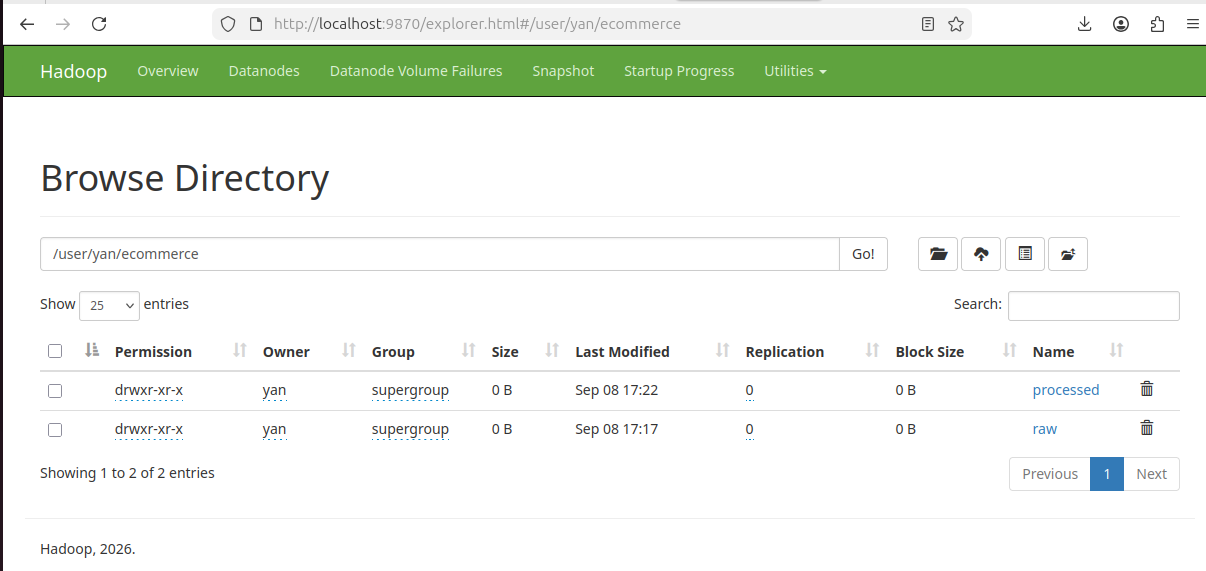

Memisahkan folder raw dan processed di HDFS itu sangat penting supaya data mentah tetap aman dan tidak tercampur dengan hasil olahan. Kalau semuanya digabung dalam satu folder, dapat membuat jadi bingung membedakan mana file asli dan mana yang sudah diproses (misalnya yang sudah ditambah kolom total_pendapatan atau sudah di-groupby). Selain itu, jika ada kesalahan saat mengolah data misalnya rumus perhitungan pendapatan salah saya masih punya data mentah asli di raw untuk diproses ulang dari awal, tanpa perlu mengunduh ulang dari sumbernya. Struktur folder yang rapi seperti ini juga memudahkan kalau nanti pekerjaan ini dikerjakan bersama tim, karena setiap orang tahu persis folder mana yang boleh diubah dan mana yang harus dijaga tetap asli.